In [ ]:
from pathlib import Path

import joblib
import numpy as np
from affine import Affine
from smoothify import smoothify

# Load clustering results from joblib file
fpath = Path(
    "output/PPCX_Tele_2020-07-24_mcmc/2020-07-24_kinematic_clustering_cleaned.joblib"
)
data = joblib.load(fpath)

X = data["X"]
Y = data["Y"]
kin_cluster_grid = data["kin_cluster_grid"]
cluster_grid = kin_cluster_grid

Vectorized 5 unique clusters.


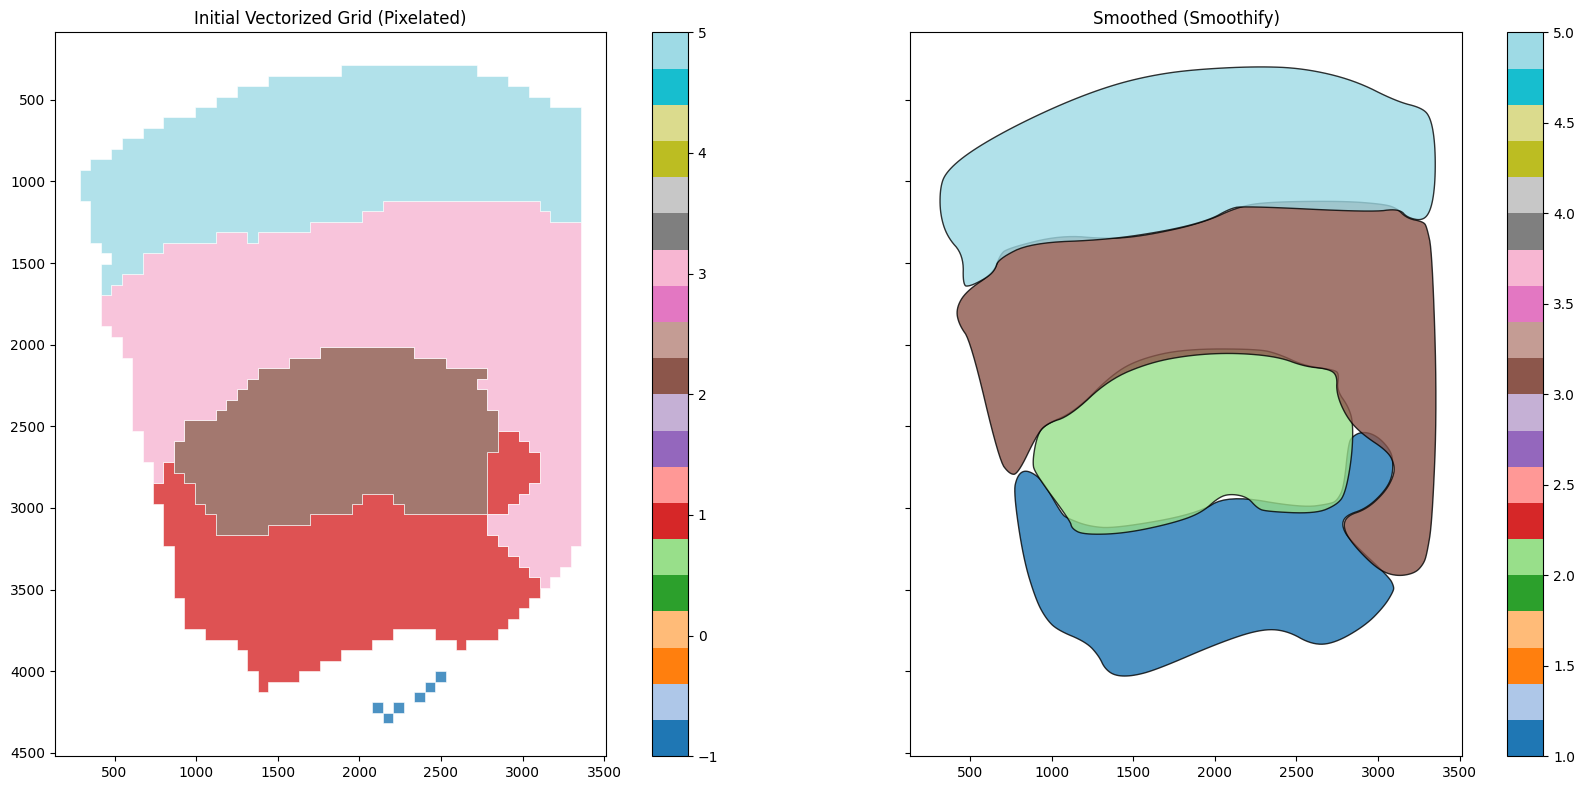

In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio.features
from shapely.geometry import shape

# 1. Setup Transform and Mask
# Calculate pixel size (dx, dy) and origin
dx = X[0, 1] - X[0, 0]
dy = Y[1, 0] - Y[0, 0]
x_origin = X[0, 0] - dx / 2
y_origin = Y[0, 0] - dy / 2
transform = Affine(dx, 0, x_origin, 0, dy, y_origin)

# Create mask for valid pixels (ignore NaNs)
mask = ~np.isnan(cluster_grid)
# Ensure data is adequate for shapes (int32 is safer for IDs, but float works too)
grid_data = cluster_grid

# 2. Direct Vectorization of the Grid
# shapes returns a generator of (geojson_geometry, value)
shapes_gen = rasterio.features.shapes(grid_data, mask=mask, transform=transform)

# Create GeoDataFrame directly from shapes
# We convert values to int for cleaner IDs
polygons_list = [
    {"geometry": shape(geom), "cluster_id": int(val)} for geom, val in shapes_gen
]
gdf = gpd.GeoDataFrame(polygons_list)

# Dissolve geometries by cluster_id to create single MultiPolygons for each cluster
gdf_initial = gdf.dissolve(by="cluster_id", as_index=False)

print(f"Vectorized {len(gdf_initial)} unique clusters.")

# 3. Apply Smoothify
# Segment length should match the raster resolution (dx) for faithful smoothing
smoothed_gdf = smoothify(
    gdf_initial,
    segment_length=abs(dx),
    smooth_iterations=3,
    merge_collection=True,  # Ensures topology is shared between clusters
    merge_field="cluster_id",  # Technically redundant after dissolve, but good practice
)

# Drop empty geometries or non-classified clusters (-1) if any
smoothed_gdf = smoothed_gdf[
    ~smoothed_gdf["geometry"].is_empty & (smoothed_gdf["cluster_id"] != -1)
].reset_index(drop=True)

# 4. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True)

# Plot Initial Pixelated vectors
gdf_initial.plot(
    ax=ax1,
    column="cluster_id",
    cmap="tab20",
    edgecolor="white",
    linewidth=0.5,
    alpha=0.8,
    legend=True,
)
ax1.set_title("Initial Vectorized Grid (Pixelated)")
ax1.set_aspect("equal")

# Plot Smoothed vectors
smoothed_gdf.plot(
    ax=ax2,
    column="cluster_id",
    cmap="tab20",
    edgecolor="black",
    linewidth=1.0,
    alpha=0.8,
    legend=True,
)
ax2.set_title("Smoothed (Smoothify)")
ax2.set_aspect("equal")

# Invert Y axis to match image coordinates (Top-Left origin)
if dy > 0:
    ax1.invert_yaxis()

plt.tight_layout()
plt.show()
